# Online Retail (UCI 352) — Unsupervised Customer Segmentation (RFM)

**Business goal.** Segment customers of a UK online gift retailer using
Recency–Frequency–Monetary behavior so marketing can prioritize VIP retention,
reactivation, and low-cost automation.

**Dataset note.** This is the **original single-year** Online Retail dataset
(Dec 2010–Dec 2011), predecessor to Online Retail II. Column names differ from
“II” — we use this file’s real names throughout:
`InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`,
`UnitPrice`, `CustomerID`, `Country`.

## Important: this is unsupervised learning

There is **no ground-truth segment label**. We do **not** report accuracy,
confusion matrices, or classification reports. Metrics are **internal** cluster
validation (Silhouette ↑, Davies–Bouldin ↓, Calinski–Harabasz ↑) plus business
profiles (size, mean RFM, share of monetary value).

Pipeline: EDA → RFM engineering → **PyCaret survey** → pick **best 2** →
**scikit-learn** re-implementation with real hyperparameter sweeps.

## 1. Setup

In [1]:
from __future__ import annotations

import random
import sys
import time
import warnings
from pathlib import Path

import matplotlib

matplotlib.use("module://matplotlib_inline.backend_inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import (
    AffinityPropagation,
    AgglomerativeClustering,
    Birch,
    DBSCAN,
    KMeans,
    MeanShift,
    OPTICS,
    SpectralClustering,
    estimate_bandwidth,
)
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 4.5)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

import matplotlib
import pycaret
import sklearn
import ucimlrepo

print("Python:", sys.version.split()[0])
print("Kernel expectation: customer-segmentation-project")
print("pycaret:", pycaret.__version__)
print("sklearn:", sklearn.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("ucimlrepo:", getattr(ucimlrepo, "__version__", "installed"))

Python: 3.13.13
Kernel expectation: customer-segmentation-project
pycaret: 4.0.0a8
sklearn: 1.9.0
pandas: 3.0.3
numpy: 2.5.1
matplotlib: 3.11.0
seaborn: 0.13.2
ucimlrepo: installed


## 2. Data acquisition — UCI Online Retail (id 352, CC BY 4.0)

Prefer `data.original` so invoice/stock identifiers are included (they sit in
`data.ids` when split). Cancellations: `InvoiceNo` values starting with `C`.

In [2]:
from ucimlrepo import fetch_ucirepo

retail = fetch_ucirepo(id=352)
print("features shape/cols:", None if retail.data.features is None else (retail.data.features.shape, list(retail.data.features.columns)))
print("targets:", retail.data.targets)
print("ids:", None if retail.data.ids is None else (retail.data.ids.shape, list(retail.data.ids.columns)))
print("original:", None if retail.data.original is None else (retail.data.original.shape, list(retail.data.original.columns)))

# Use original for full transactional schema
raw = retail.data.original.copy() if retail.data.original is not None else retail.data.features.copy()
# If features missing invoice cols, join ids
if "InvoiceNo" not in raw.columns and retail.data.ids is not None:
    raw = pd.concat([retail.data.ids.reset_index(drop=True), retail.data.features.reset_index(drop=True)], axis=1)

print("Working shape:", raw.shape)
print("Working columns:", list(raw.columns))
display(raw.head())
print(raw.dtypes)

# Hard-require 352 naming
for col in ["InvoiceNo", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID", "Country"]:
    assert col in raw.columns, f"Missing expected column {col}; got {list(raw.columns)}"

features shape/cols: ((541909, 6), ['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'])
targets: None
ids: ((541909, 2), ['InvoiceNo', 'StockCode'])
original: ((541909, 8), ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'])
Working shape: (541909, 8)
Working columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


## 3. EDA (transaction level, before RFM collapse)

Shape: (541909, 8)


Missingness:


,n_missing,pct
InvoiceNo,0,0.000000
StockCode,0,0.000000
Description,1454,0.268311
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
CustomerID,135080,24.926694
Country,0,0.000000


Cancellations: 9,288 (1.71%)
Unique invoices: 25,900
Unique CustomerID (non-null): 4,372
Missing CustomerID rows: 135,080
Date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00


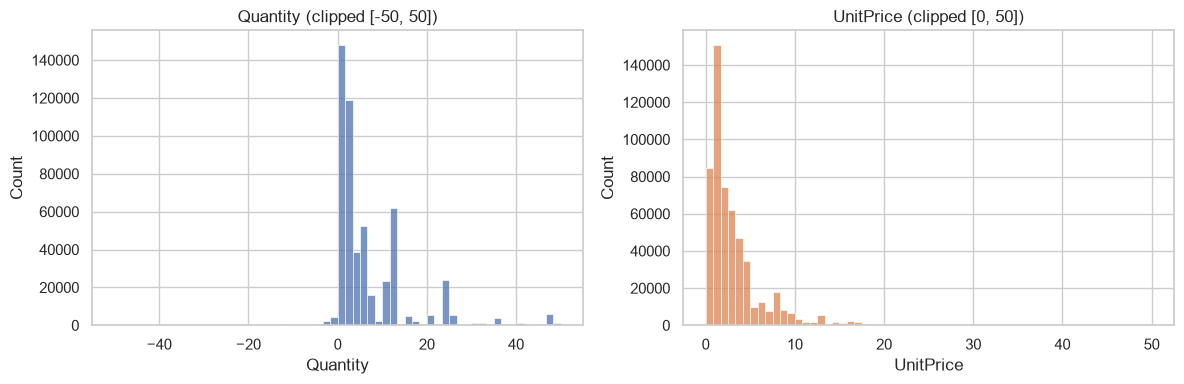

Quantity describe:
 count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

UnitPrice describe:
 count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64


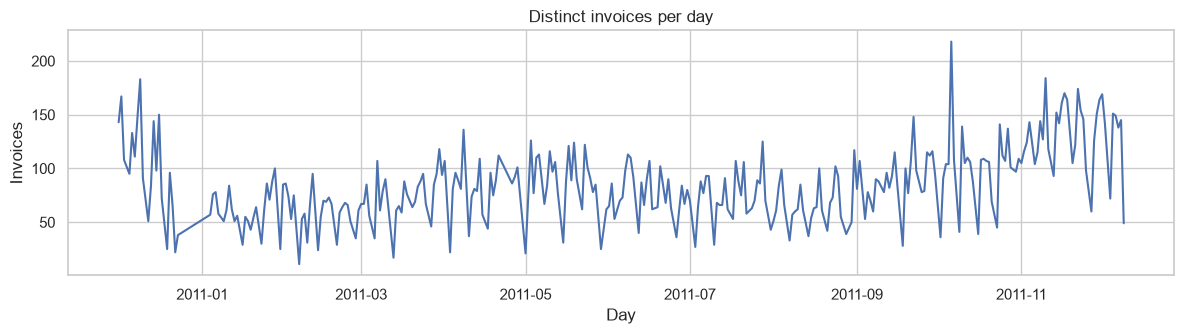

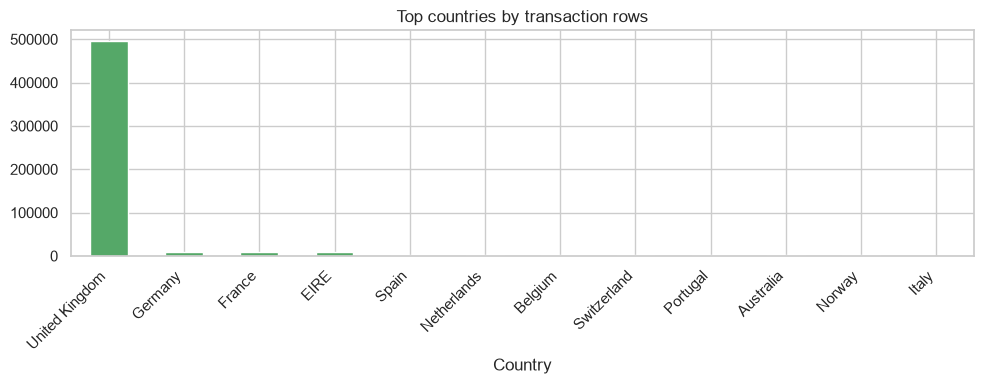

,n_rows
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


In [3]:
print("Shape:", raw.shape)
miss = raw.isna().sum().to_frame("n_missing")
miss["pct"] = 100 * miss["n_missing"] / len(raw)
print("Missingness:")
display(miss)

raw = raw.copy()
raw["InvoiceNo"] = raw["InvoiceNo"].astype(str)
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"], errors="coerce")
raw["is_cancel"] = raw["InvoiceNo"].str.startswith("C")

print(f"Cancellations: {raw['is_cancel'].sum():,} ({100*raw['is_cancel'].mean():.2f}%)")
print(f"Unique invoices: {raw['InvoiceNo'].nunique():,}")
print(f"Unique CustomerID (non-null): {raw['CustomerID'].nunique(dropna=True):,}")
print(f"Missing CustomerID rows: {raw['CustomerID'].isna().sum():,}")
print(f"Date range: {raw['InvoiceDate'].min()} → {raw['InvoiceDate'].max()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(raw.loc[raw["Quantity"].between(-50, 50), "Quantity"], bins=60, ax=axes[0])
axes[0].set_title("Quantity (clipped [-50, 50])")
sns.histplot(raw.loc[raw["UnitPrice"].between(0, 50), "UnitPrice"], bins=60, ax=axes[1], color="C1")
axes[1].set_title("UnitPrice (clipped [0, 50])")
plt.tight_layout()
plt.show()

print("Quantity describe:\n", raw["Quantity"].describe())
print("\nUnitPrice describe:\n", raw["UnitPrice"].describe())

daily = (
    raw.dropna(subset=["InvoiceDate"])
    .assign(day=lambda d: d["InvoiceDate"].dt.date)
    .groupby("day")["InvoiceNo"]
    .nunique()
    .sort_index()
)
fig, ax = plt.subplots(figsize=(12, 3.5))
daily.plot(ax=ax)
ax.set_title("Distinct invoices per day")
ax.set_xlabel("Day")
ax.set_ylabel("Invoices")
plt.tight_layout()
plt.show()

country_counts = raw["Country"].value_counts().head(12)
fig, ax = plt.subplots(figsize=(10, 4))
country_counts.plot(kind="bar", ax=ax, color="C2")
ax.set_title("Top countries by transaction rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
display(country_counts.to_frame("n_rows"))

## 4. Feature engineering — RFM

Clean: drop cancels, missing `CustomerID`, non-positive quantity/price.
Aggregate: Recency (days to max date), Frequency (nunique InvoiceNo),
Monetary (`sum(Quantity * UnitPrice)`). Log-transform Frequency/Monetary if
skew on **this** dataset justifies it, then `StandardScaler`.

Raw rows: 541,909
Cleaned rows: 397,884
Customers: 4,338
Snapshot date: 2011-12-09 12:50:00


RFM shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12347,1,7,4310.00
2,12348,74,4,1797.24
3,12349,18,1,1757.55
4,12350,309,1,334.40


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,307.415000
50%,50.000000,2.000000,674.485000
75%,141.000000,5.000000,1661.740000
max,373.000000,209.000000,280206.020000


Skewness raw RFM:
 Recency       1.246048
Frequency    12.067031
Monetary     19.324953
dtype: float64


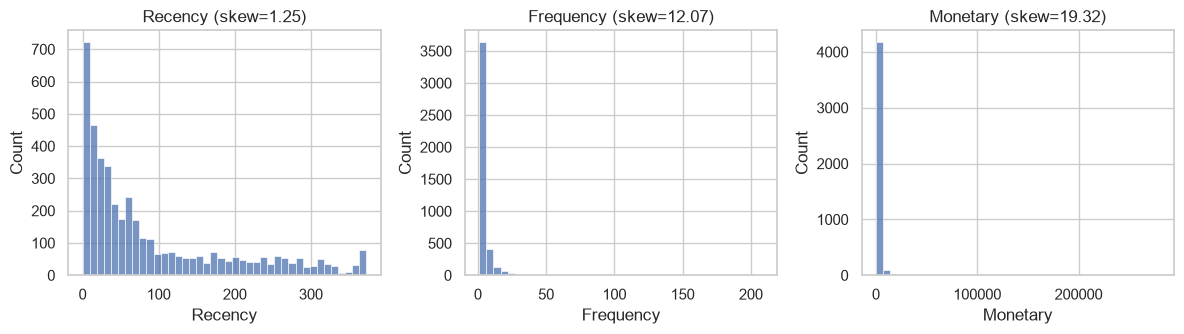

log1p(Frequency) because skew=12.07 > 1
log1p(Monetary) because skew=19.32 > 1
Clustering features: ['Recency', 'log_Frequency', 'log_Monetary']


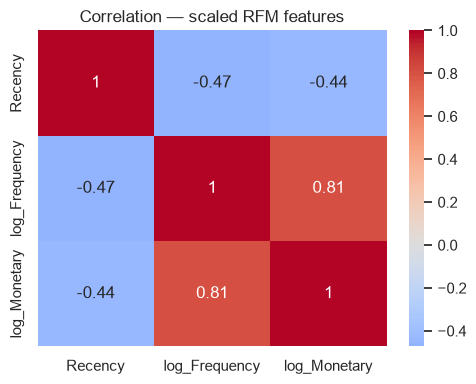

In [4]:
tx = raw.loc[
    (~raw["is_cancel"])
    & raw["CustomerID"].notna()
    & (raw["Quantity"] > 0)
    & (raw["UnitPrice"] > 0)
].copy()
tx["line_total"] = tx["Quantity"] * tx["UnitPrice"]
print(f"Raw rows: {len(raw):,}")
print(f"Cleaned rows: {len(tx):,}")
print(f"Customers: {tx['CustomerID'].nunique():,}")

snapshot = tx["InvoiceDate"].max()
print("Snapshot date:", snapshot)

rfm = (
    tx.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda s: (snapshot - s.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("line_total", "sum"),
    )
    .reset_index()
)
rfm["CustomerID"] = rfm["CustomerID"].astype(int)
print("RFM shape:", rfm.shape)
display(rfm.head())
display(rfm[["Recency", "Frequency", "Monetary"]].describe())

feat_cols = ["Recency", "Frequency", "Monetary"]
skew_vals = rfm[feat_cols].skew()
print("Skewness raw RFM:\n", skew_vals)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, feat_cols):
    sns.histplot(rfm[col], bins=40, ax=ax)
    ax.set_title(f"{col} (skew={skew_vals[col]:.2f})")
plt.tight_layout()
plt.show()

log_cols = []
for col in ["Frequency", "Monetary"]:
    if skew_vals[col] > 1.0:
        log_cols.append(col)
        print(f"log1p({col}) because skew={skew_vals[col]:.2f} > 1")
    else:
        print(f"no log for {col} (skew={skew_vals[col]:.2f})")

rfm_model = rfm.copy()
for col in log_cols:
    rfm_model[f"log_{col}"] = np.log1p(rfm_model[col])

cluster_feature_names = ["Recency"] + [
    f"log_{c}" if c in log_cols else c for c in ["Frequency", "Monetary"]
]
print("Clustering features:", cluster_feature_names)

X_unscaled = rfm_model[cluster_feature_names].to_numpy(dtype=float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unscaled)
rfm_scaled = pd.DataFrame(X_scaled, columns=cluster_feature_names, index=rfm.index)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(rfm_scaled.corr(), annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation — scaled RFM features")
plt.tight_layout()
plt.show()

## 5. Part 1 — PyCaret survey → best 2

Pre-scaled features enter PyCaret with `normalize=False` so Part 1 and Part 2
share the same matrix. Density methods: factor **noise (−1)** into selection.

In [5]:
from pycaret.clustering import ClusteringExperiment

cluster_df = rfm_scaled.copy()
print("Survey matrix:", cluster_df.shape)
exp = ClusteringExperiment(session_id=SEED, normalize=False).fit(cluster_df)
available = exp.models()
display(available)
candidate_ids = [m for m in ["kmeans", "hclust", "birch", "dbscan", "optics", "sc", "meanshift", "ap"] if m in available.index]
print("Candidates:", candidate_ids)


def parse_cluster_labels(series: pd.Series) -> np.ndarray:
    s = series.astype(str).str.replace("Cluster ", "", regex=False)
    return pd.to_numeric(s, errors="coerce").fillna(-1).astype(int).to_numpy()


def internal_metrics(X: np.ndarray, labels: np.ndarray) -> dict:
    labels = np.asarray(labels)
    mask = labels >= 0
    n_noise = int((~mask).sum())
    n = int(mask.sum())
    uniq = sorted(set(labels[mask].tolist())) if n else []
    out = {
        "n_clusters": len(uniq),
        "n_noise": n_noise,
        "noise_pct": 100.0 * n_noise / len(labels) if len(labels) else np.nan,
        "largest_cluster_pct": np.nan,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
    }
    if not uniq:
        return out
    sizes = pd.Series(labels[mask]).value_counts()
    out["largest_cluster_pct"] = 100.0 * sizes.iloc[0] / n
    if len(uniq) >= 2 and n > len(uniq):
        out["silhouette"] = float(silhouette_score(X[mask], labels[mask]))
        out["davies_bouldin"] = float(davies_bouldin_score(X[mask], labels[mask]))
        out["calinski_harabasz"] = float(calinski_harabasz_score(X[mask], labels[mask]))
    return out


survey_rows = []
for mid in candidate_ids:
    print(f"\n--- Survey: {mid} ---")
    t1 = time.time()
    try:
        kwargs = {}
        if mid in {"kmeans", "hclust", "birch", "sc"}:
            kwargs["num_clusters"] = 4
        res = exp.create_model(mid, verbose=False, **kwargs)
        y = parse_cluster_labels(exp.assign_model(res.pipeline)["Cluster"])
        m = internal_metrics(X_scaled, y)
        row = {"model": mid, "seconds": round(time.time() - t1, 2), "error": "", **m}
        print(row)
        survey_rows.append(row)
    except Exception as exc:
        survey_rows.append(
            {
                "model": mid,
                "seconds": round(time.time() - t1, 2),
                "error": str(exc),
                "n_clusters": np.nan,
                "n_noise": np.nan,
                "noise_pct": np.nan,
                "largest_cluster_pct": np.nan,
                "silhouette": np.nan,
                "davies_bouldin": np.nan,
                "calinski_harabasz": np.nan,
            }
        )
        print("FAIL", exc)

survey = pd.DataFrame(survey_rows)
print("\n=== Full survey ===")
display(survey.sort_values("silhouette", ascending=False, na_position="last"))

survey["viable"] = (
    (survey["error"].fillna("") == "")
    & survey["silhouette"].notna()
    & (survey["n_clusters"] >= 2)
    & (survey["n_clusters"] <= 25)
    & (survey["noise_pct"] <= 30)
    & (survey["largest_cluster_pct"] <= 85)
)
print("Viability filter (noise≤30%, largest≤85%, 2–25 clusters):")
display(survey[["model", "n_clusters", "noise_pct", "largest_cluster_pct", "silhouette", "viable"]])
rankable = survey.loc[survey["viable"]].copy()


def survey_score(row: pd.Series) -> float:
    if pd.isna(row["silhouette"]):
        return -1e9
    score = float(row["silhouette"])
    if pd.notna(row["calinski_harabasz"]):
        score += 0.0005 * float(row["calinski_harabasz"])
    if pd.notna(row["davies_bouldin"]):
        score -= 0.05 * float(row["davies_bouldin"])
    score -= 0.002 * max(0.0, float(row["largest_cluster_pct"]) - 60.0)
    return score


if len(rankable) < 2:
    print("WARNING: <2 models passed hard filter; relaxing to noise≤50% and largest≤95%")
    rankable = survey.loc[
        (survey["error"].fillna("") == "")
        & survey["silhouette"].notna()
        & (survey["n_clusters"] >= 2)
        & (survey["n_clusters"] <= 50)
        & (survey["noise_pct"] <= 50)
        & (survey["largest_cluster_pct"] <= 95)
    ].copy()

rankable["score"] = rankable.apply(survey_score, axis=1)
rankable = rankable.sort_values("score", ascending=False)
display(rankable)
if len(rankable) < 2:
    raise RuntimeError(survey)
best_two = rankable["model"].head(2).tolist()
print("Best 2 from survey:", best_two)
for i, mid in enumerate(best_two, 1):
    r = rankable.loc[rankable["model"] == mid].iloc[0]
    print(
        f"  #{i} {mid}: Sil={r['silhouette']:.4f}, CH={r['calinski_harabasz']:.1f}, "
        f"DB={r['davies_bouldin']:.4f}, noise%={r['noise_pct']:.1f}, largest%={r['largest_cluster_pct']:.1f}"
    )

Survey matrix: (4338, 3)


,Name,Reference,Turbo
ID,,,
kmeans,K-Means Clustering,sklearn.cluster._kmeans.KMeans,False
ap,Affinity Propagation,sklearn.cluster._affinity_propagation.Affinity...,False
meanshift,Mean Shift Clustering,sklearn.cluster._mean_shift.MeanShift,False
sc,Spectral Clustering,sklearn.cluster._spectral.SpectralClustering,False
hclust,Agglomerative Clustering,sklearn.cluster._agglomerative.AgglomerativeCl...,False
dbscan,Density-Based Spatial Clustering,sklearn.cluster._dbscan.DBSCAN,False
optics,OPTICS Clustering,sklearn.cluster._optics.OPTICS,False
birch,Birch Clustering,sklearn.cluster._birch.Birch,False


Candidates: ['kmeans', 'hclust', 'birch', 'dbscan', 'optics', 'sc', 'meanshift', 'ap']

--- Survey: kmeans ---


{'model': 'kmeans', 'seconds': 1.65, 'error': '', 'n_clusters': 4, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': np.float64(33.40248962655602), 'silhouette': 0.3792045627020082, 'davies_bouldin': 0.8604050870082576, 'calinski_harabasz': 4354.112405890751}

--- Survey: hclust ---


{'model': 'hclust', 'seconds': 1.36, 'error': '', 'n_clusters': 4, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': np.float64(44.65191332411249), 'silhouette': 0.37409116622364097, 'davies_bouldin': 0.8054693393039654, 'calinski_harabasz': 3623.1258857974026}

--- Survey: birch ---


...

,model,seconds,error,n_clusters,n_noise,noise_pct,largest_cluster_pct,silhouette,davies_bouldin,calinski_harabasz
4,optics,97.63,,247,2407,55.486399,1.398239,0.550344,0.555249,3102.858640
5,sc,1.33,,4,0,0.000000,99.400645,0.543799,1.227589,90.360079
0,kmeans,1.65,,4,0,0.000000,33.402490,0.379205,0.860405,4354.112406
1,hclust,1.36,,4,0,0.000000,44.651913,0.374091,0.805469,3623.125886
3,dbscan,0.53,,2,48,1.106501,65.337995,0.326879,1.122169,2449.651633
6,meanshift,8.17,,4,0,0.000000,97.095436,0.262329,1.531821,222.811108
2,birch,0.94,,4,0,0.000000,68.487782,0.261266,0.884785,1448.822106
7,ap,31.67,,158,0,0.000000,2.858460,0.259934,0.834001,1131.426711


Viability filter (noise≤30%, largest≤85%, 2–25 clusters):


,model,n_clusters,noise_pct,largest_cluster_pct,silhouette,viable
0,kmeans,4,0.000000,33.402490,0.379205,True
1,hclust,4,0.000000,44.651913,0.374091,True
2,birch,4,0.000000,68.487782,0.261266,True
3,dbscan,2,1.106501,65.337995,0.326879,True
4,optics,247,55.486399,1.398239,0.550344,False
5,sc,4,0.000000,99.400645,0.543799,False
6,meanshift,4,0.000000,97.095436,0.262329,False
7,ap,158,0.000000,2.858460,0.259934,False


,model,seconds,error,n_clusters,n_noise,noise_pct,largest_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,viable,score
0,kmeans,1.65,,4,0,0.000000,33.402490,0.379205,0.860405,4354.112406,True,2.513241
1,hclust,1.36,,4,0,0.000000,44.651913,0.374091,0.805469,3623.125886,True,2.145381
3,dbscan,0.53,,2,48,1.106501,65.337995,0.326879,1.122169,2449.651633,True,1.484920
2,birch,0.94,,4,0,0.000000,68.487782,0.261266,0.884785,1448.822106,True,0.924462


Best 2 from survey: ['kmeans', 'hclust']
  #1 kmeans: Sil=0.3792, CH=4354.1, DB=0.8604, noise%=0.0, largest%=33.4
  #2 hclust: Sil=0.3741, CH=3623.1, DB=0.8055, noise%=0.0, largest%=44.7


## 6. Part 2 — Proper scikit-learn re-implementation of the best 2


Proper sklearn: kmeans → kmeans


,k,inertia,n_clusters,n_noise,noise_pct,largest_cluster_pct,silhouette,davies_bouldin,calinski_harabasz
0,2,6872.757289,2,0,0.0,57.999078,0.406390,0.915233,3874.507025
1,3,4298.644789,3,0,0.0,46.934071,0.415646,0.824667,4394.545846
2,4,3242.054949,4,0,0.0,33.356385,0.380497,0.857012,4354.407729
3,5,2760.927874,5,0,0.0,27.777778,0.343331,0.940857,4022.815872
4,6,2397.223499,6,0,0.0,25.610881,0.330665,0.976253,3837.140923
5,7,2166.671613,7,0,0.0,22.360535,0.299834,1.025949,3613.894666
6,8,1960.504884,8,0,0.0,20.401107,0.300510,0.999477,3487.586638
7,9,1818.897023,9,0,0.0,17.680959,0.281262,1.036451,3330.591085
8,10,1687.855958,10,0,0.0,17.058552,0.282450,1.020304,3226.977073


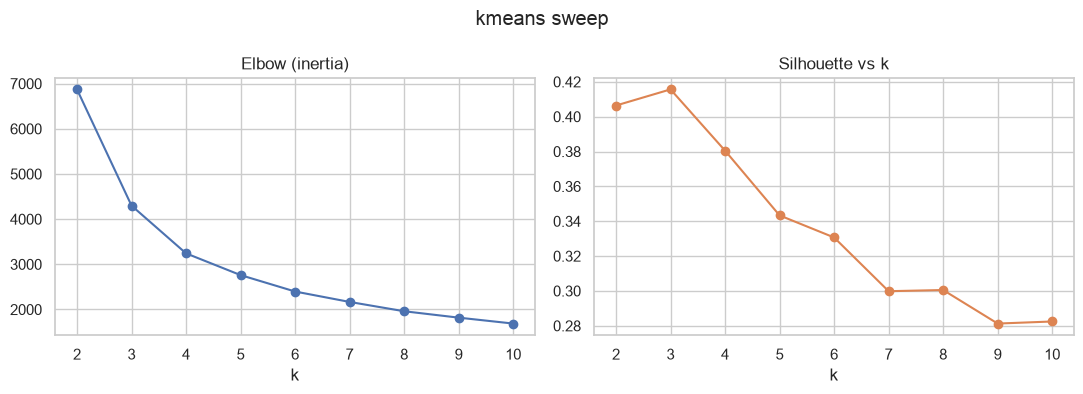

Chosen k=3 (Silhouette=0.4156)


Final metrics: {'n_clusters': 3, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': np.float64(46.93407100046104), 'silhouette': 0.4156459171082181, 'davies_bouldin': 0.8246674566449164, 'calinski_harabasz': 4394.545846493374}
Params: {'n_clusters': 3}


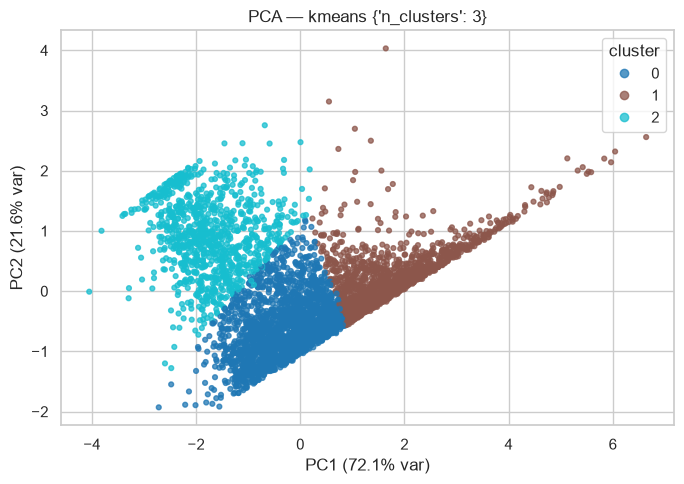

Profiles (original RFM units):


,cluster,n_customers,mean_Recency,mean_Frequency,mean_Monetary,total_Monetary,pct_customers,pct_monetary
1,1,1323,29.100529,9.829932,5494.341156,7269013.350,30.497925,81.569752
0,0,2036,53.857073,2.046169,615.235984,1252620.463,46.934071,14.056370
2,2,979,254.271706,1.390194,398.134924,389774.091,22.568004,4.373878



Proper sklearn: hclust → hclust


,k,inertia,n_clusters,n_noise,noise_pct,largest_cluster_pct,silhouette,davies_bouldin,calinski_harabasz
0,2,NaN,2,0,0.0,64.776395,0.399909,0.891886,3690.981503
1,3,NaN,3,0,0.0,44.651913,0.395890,0.845488,4031.943449
2,4,NaN,4,0,0.0,44.651913,0.374091,0.805469,3623.125886
3,5,NaN,5,0,0.0,31.512218,0.298999,0.981541,3413.692784
4,6,NaN,6,0,0.0,25.334255,0.276065,1.066884,3213.529547
5,7,NaN,7,0,0.0,25.334255,0.252642,1.132208,3113.037843
6,8,NaN,8,0,0.0,25.334255,0.239763,1.107128,2891.675509
7,9,NaN,9,0,0.0,18.556939,0.227435,1.182342,2744.322325
8,10,NaN,10,0,0.0,18.556939,0.233272,1.157666,2636.228152


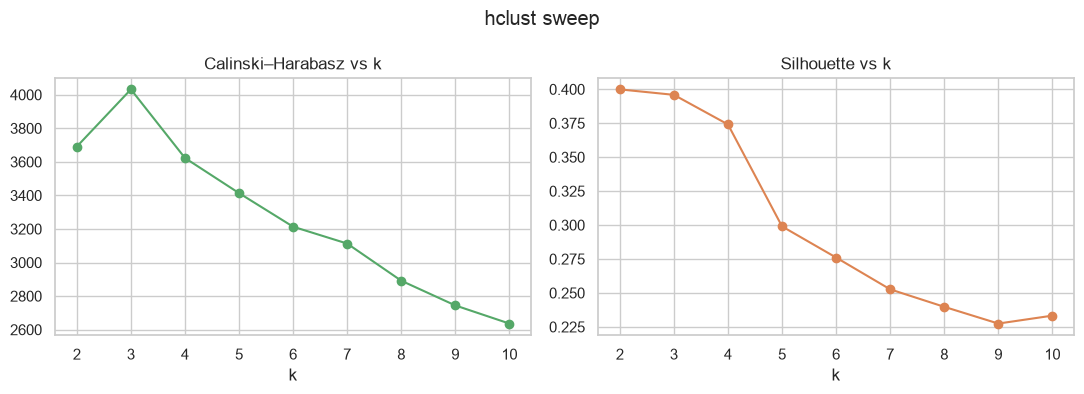

Chosen k=2 (Silhouette=0.3999)


Final metrics: {'n_clusters': 2, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': np.float64(64.77639465191332), 'silhouette': 0.3999086874336099, 'davies_bouldin': 0.8918858803924451, 'calinski_harabasz': 3690.9815030227805}
Params: {'n_clusters': 2}


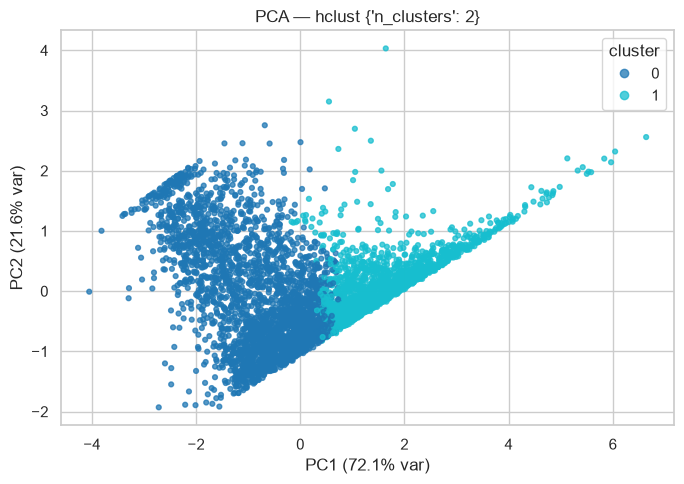

Profiles (original RFM units):


,cluster,n_customers,mean_Recency,mean_Frequency,mean_Monetary,total_Monetary,pct_customers,pct_monetary
1,1,1528,28.798429,9.003272,4889.208600,7470710.741,35.223605,83.833114
0,0,2810,125.651601,1.699288,512.703617,1440697.163,64.776395,16.166886


In [6]:
ALGO_MAP = {
    "kmeans": "kmeans",
    "hclust": "hclust",
    "birch": "birch",
    "sc": "sc",
    "dbscan": "dbscan",
    "optics": "optics",
    "meanshift": "meanshift",
    "ap": "ap",
}


def fit_sklearn(algo: str, X: np.ndarray, **params):
    if algo == "kmeans":
        return KMeans(n_clusters=params.get("n_clusters", 4), random_state=SEED, n_init=10).fit(X)
    if algo == "hclust":
        return AgglomerativeClustering(n_clusters=params.get("n_clusters", 4)).fit(X)
    if algo == "birch":
        return Birch(n_clusters=params.get("n_clusters", 4)).fit(X)
    if algo == "sc":
        return SpectralClustering(
            n_clusters=params.get("n_clusters", 4),
            random_state=SEED,
            assign_labels="kmeans",
            affinity="nearest_neighbors",
            n_neighbors=min(15, max(2, len(X) // 50)),
        ).fit(X)
    if algo == "dbscan":
        return DBSCAN(eps=params.get("eps", 0.8), min_samples=params.get("min_samples", 10)).fit(X)
    if algo == "optics":
        return OPTICS(min_samples=params.get("min_samples", 10), xi=params.get("xi", 0.05)).fit(X)
    if algo == "meanshift":
        bw = params.get("bandwidth")
        if bw is None:
            bw = estimate_bandwidth(X, quantile=0.2, n_samples=min(500, len(X)), random_state=SEED)
            if not np.isfinite(bw) or bw <= 0:
                bw = 1.0
        return MeanShift(bandwidth=bw, bin_seeding=True).fit(X)
    if algo == "ap":
        return AffinityPropagation(random_state=SEED, damping=params.get("damping", 0.9)).fit(X)
    raise ValueError(algo)


def labels_from_model(model) -> np.ndarray:
    return np.asarray(model.labels_)


def sweep_k(algo: str, X: np.ndarray, ks=range(2, 11)):
    rows = []
    for k in ks:
        model = fit_sklearn(algo, X, n_clusters=k)
        y = labels_from_model(model)
        m = internal_metrics(X, y)
        rows.append({"k": k, "inertia": getattr(model, "inertia_", np.nan), **m})
    return pd.DataFrame(rows)


def profile_clusters(rfm_df: pd.DataFrame, labels: np.ndarray) -> pd.DataFrame:
    tmp = rfm_df.copy()
    tmp["cluster"] = labels
    id_col = "CustomerID"
    prof = (
        tmp.groupby("cluster")
        .agg(
            n_customers=(id_col, "count"),
            mean_Recency=("Recency", "mean"),
            mean_Frequency=("Frequency", "mean"),
            mean_Monetary=("Monetary", "mean"),
            total_Monetary=("Monetary", "sum"),
        )
        .reset_index()
    )
    prof["pct_customers"] = 100 * prof["n_customers"] / prof["n_customers"].sum()
    prof["pct_monetary"] = 100 * prof["total_Monetary"] / prof["total_Monetary"].sum()
    return prof.sort_values("mean_Monetary", ascending=False)


def pca_scatter(X: np.ndarray, labels: np.ndarray, title: str):
    pca = PCA(n_components=2, random_state=SEED)
    Z = pca.fit_transform(X)
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=labels, cmap="tab10", s=12, alpha=0.75)
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)")
    ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)")
    ax.legend(*sc.legend_elements(), title="cluster")
    plt.tight_layout()
    plt.show()


proper_results = {}
for mid in best_two:
    algo = ALGO_MAP[mid]
    print("\n" + "=" * 70)
    print(f"Proper sklearn: {mid} → {algo}")
    print("=" * 70)

    if algo in {"kmeans", "hclust", "birch", "sc"}:
        sweep = sweep_k(algo, X_scaled)
        display(sweep)
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        if algo == "kmeans" and sweep["inertia"].notna().any():
            axes[0].plot(sweep["k"], sweep["inertia"], marker="o")
            axes[0].set_title("Elbow (inertia)")
        else:
            axes[0].plot(sweep["k"], sweep["calinski_harabasz"], marker="o", color="C2")
            axes[0].set_title("Calinski–Harabasz vs k")
        axes[1].plot(sweep["k"], sweep["silhouette"], marker="o", color="C1")
        axes[1].set_title("Silhouette vs k")
        for ax in axes:
            ax.set_xlabel("k")
        plt.suptitle(f"{algo} sweep")
        plt.tight_layout()
        plt.show()
        viable = sweep.loc[sweep["largest_cluster_pct"] < 92]
        if viable.empty:
            viable = sweep
        best_row = viable.sort_values(["silhouette", "calinski_harabasz"], ascending=[False, False]).iloc[0]
        best_k = int(best_row["k"])
        print(f"Chosen k={best_k} (Silhouette={best_row['silhouette']:.4f})")
        model = fit_sklearn(algo, X_scaled, n_clusters=best_k)
        y = labels_from_model(model)
        params_used = {"n_clusters": best_k}
        sweep_table = sweep

    elif algo == "dbscan":
        nn = NearestNeighbors(n_neighbors=10).fit(X_scaled)
        dists, _ = nn.kneighbors(X_scaled)
        kth = np.sort(dists[:, -1])
        candidates = sorted(set(np.round(np.quantile(kth, [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]), 3).tolist()))
        rows = []
        for eps in candidates:
            for ms in [5, 10, 15]:
                model = fit_sklearn("dbscan", X_scaled, eps=eps, min_samples=ms)
                m = internal_metrics(X_scaled, labels_from_model(model))
                rows.append({"eps": eps, "min_samples": ms, **m})
        sweep = pd.DataFrame(rows)
        display(sweep.sort_values("silhouette", ascending=False).head(12))
        fig, ax = plt.subplots(figsize=(8, 3.5))
        ax.plot(kth)
        ax.set_title("k-distance plot")
        plt.tight_layout()
        plt.show()
        viable = sweep.loc[(sweep["n_clusters"] >= 2) & (sweep["noise_pct"] <= 40)]
        if viable.empty:
            viable = sweep.loc[sweep["n_clusters"] >= 2]
        best_row = viable.sort_values("silhouette", ascending=False).iloc[0]
        params_used = {"eps": float(best_row["eps"]), "min_samples": int(best_row["min_samples"])}
        model = fit_sklearn("dbscan", X_scaled, **params_used)
        y = labels_from_model(model)
        sweep_table = sweep

    elif algo == "optics":
        rows = []
        for ms in [5, 10, 15, 20]:
            for xi in [0.03, 0.05, 0.1]:
                model = fit_sklearn("optics", X_scaled, min_samples=ms, xi=xi)
                m = internal_metrics(X_scaled, labels_from_model(model))
                rows.append({"min_samples": ms, "xi": xi, **m})
        sweep = pd.DataFrame(rows)
        display(sweep.sort_values("silhouette", ascending=False).head(12))
        viable = sweep.loc[(sweep["n_clusters"] >= 2) & (sweep["noise_pct"] <= 40)]
        if viable.empty:
            viable = sweep.loc[sweep["n_clusters"] >= 2]
        best_row = viable.sort_values("silhouette", ascending=False).iloc[0]
        params_used = {"min_samples": int(best_row["min_samples"]), "xi": float(best_row["xi"])}
        model = fit_sklearn("optics", X_scaled, **params_used)
        y = labels_from_model(model)
        sweep_table = sweep

    elif algo == "meanshift":
        rows = []
        for q in [0.1, 0.15, 0.2, 0.25, 0.3]:
            bw = estimate_bandwidth(X_scaled, quantile=q, n_samples=min(500, len(X_scaled)), random_state=SEED)
            if not np.isfinite(bw) or bw <= 0:
                continue
            model = fit_sklearn("meanshift", X_scaled, bandwidth=bw)
            m = internal_metrics(X_scaled, labels_from_model(model))
            rows.append({"quantile": q, "bandwidth": bw, **m})
        sweep = pd.DataFrame(rows)
        display(sweep)
        best_row = sweep.loc[sweep["n_clusters"] >= 2].sort_values("silhouette", ascending=False).iloc[0]
        params_used = {"bandwidth": float(best_row["bandwidth"]), "quantile": float(best_row["quantile"])}
        model = fit_sklearn("meanshift", X_scaled, bandwidth=params_used["bandwidth"])
        y = labels_from_model(model)
        sweep_table = sweep

    elif algo == "ap":
        rows = []
        for damp in [0.5, 0.7, 0.9]:
            model = fit_sklearn("ap", X_scaled, damping=damp)
            m = internal_metrics(X_scaled, labels_from_model(model))
            rows.append({"damping": damp, **m})
        sweep = pd.DataFrame(rows)
        display(sweep)
        best_row = sweep.sort_values("silhouette", ascending=False).iloc[0]
        params_used = {"damping": float(best_row["damping"])}
        model = fit_sklearn("ap", X_scaled, **params_used)
        y = labels_from_model(model)
        sweep_table = sweep
    else:
        raise ValueError(algo)

    metrics = internal_metrics(X_scaled, y)
    print("Final metrics:", metrics)
    print("Params:", params_used)
    pca_scatter(X_scaled, y, f"PCA — {algo} {params_used}")
    prof = profile_clusters(rfm, y)
    print("Profiles (original RFM units):")
    display(prof)
    proper_results[mid] = {
        "algo": algo,
        "params": params_used,
        "labels": y,
        "metrics": metrics,
        "profile": prof,
        "sweep": sweep_table,
    }

## 7. Side-by-side comparison of the two models

Prefer balanced, monetarily distinct segments — not only the highest Silhouette.

In [7]:
cmp_rows = []
for mid, res in proper_results.items():
    m = res["metrics"]
    cmp_rows.append(
        {
            "model": mid,
            "algo": res["algo"],
            "params": res["params"],
            "n_clusters": m["n_clusters"],
            "noise_pct": m["noise_pct"],
            "largest_cluster_pct": m["largest_cluster_pct"],
            "silhouette": m["silhouette"],
            "davies_bouldin": m["davies_bouldin"],
            "calinski_harabasz": m["calinski_harabasz"],
        }
    )
comparison = pd.DataFrame(cmp_rows)
display(comparison)

for mid, res in proper_results.items():
    usable = res["profile"].loc[res["profile"]["cluster"] >= 0]
    print(f"\n{mid}: n_clusters={res['metrics']['n_clusters']}, "
          f"largest={res['metrics']['largest_cluster_pct']:.1f}%, noise={res['metrics']['noise_pct']:.1f}%")
    if len(usable):
        print(
            "  monetary mean ratio max/min =",
            f"{usable['mean_Monetary'].max() / max(usable['mean_Monetary'].min(), 1e-9):.2f}",
        )
    display(usable)


def business_score(row) -> float:
    s = 0.0 if pd.isna(row["silhouette"]) else float(row["silhouette"])
    if row["noise_pct"] > 30:
        s -= 0.3
    if row["largest_cluster_pct"] > 85:
        s -= 0.2
    return s


comparison["business_score"] = comparison.apply(business_score, axis=1)
preferred = comparison.sort_values("business_score", ascending=False).iloc[0]
print("Preferred:", preferred["model"], preferred["params"], f"Sil={preferred['silhouette']:.4f}")

,model,algo,params,n_clusters,noise_pct,largest_cluster_pct,silhouette,davies_bouldin,calinski_harabasz
0,kmeans,kmeans,{'n_clusters': 3},3,0.0,46.934071,0.415646,0.824667,4394.545846
1,hclust,hclust,{'n_clusters': 2},2,0.0,64.776395,0.399909,0.891886,3690.981503



kmeans: n_clusters=3, largest=46.9%, noise=0.0%
  monetary mean ratio max/min = 13.80


,cluster,n_customers,mean_Recency,mean_Frequency,mean_Monetary,total_Monetary,pct_customers,pct_monetary
1,1,1323,29.100529,9.829932,5494.341156,7269013.350,30.497925,81.569752
0,0,2036,53.857073,2.046169,615.235984,1252620.463,46.934071,14.056370
2,2,979,254.271706,1.390194,398.134924,389774.091,22.568004,4.373878



hclust: n_clusters=2, largest=64.8%, noise=0.0%
  monetary mean ratio max/min = 9.54


,cluster,n_customers,mean_Recency,mean_Frequency,mean_Monetary,total_Monetary,pct_customers,pct_monetary
1,1,1528,28.798429,9.003272,4889.208600,7470710.741,35.223605,83.833114
0,0,2810,125.651601,1.699288,512.703617,1440697.163,64.776395,16.166886


Preferred: kmeans {'n_clusters': 3} Sil=0.4156


## 8. Explaining this to your manager

Numbers below come from **this notebook’s run** on UCI Online Retail (352), not
from the Online Retail II notebook.

In [8]:
pref_mid = preferred["model"]
pref = proper_results[pref_mid]
prof = pref["profile"].loc[pref["profile"]["cluster"] >= 0].sort_values(
    "mean_Monetary", ascending=False
).reset_index(drop=True)

print("MANAGER BRIEF — Online Retail (UCI 352) RFM segments")
print("=" * 60)
print(
    f"We grouped {len(rfm):,} customers (single-year Online Retail) into "
    f"{pref['metrics']['n_clusters']} segments with {pref['algo']} {pref['params']}."
)
print(
    f"Internal fit: Silhouette={pref['metrics']['silhouette']:.3f}, "
    f"Davies–Bouldin={pref['metrics']['davies_bouldin']:.3f}, "
    f"Calinski–Harabasz={pref['metrics']['calinski_harabasz']:.1f}."
)
print()

actions = [
    "VIP treatment: protect high-monetary recent buyers with high-touch retention.",
    "Growth nurture: raise frequency via bundles and loyalty for mid-tier.",
    "Reactivation: win-back for high-recency (stale) former spenders.",
    "Efficient automation: low-cost messaging for low-value infrequent buyers.",
    "Investigate: unusual recency/monetary combinations may signal data/process issues.",
]

for i, row in prof.iterrows():
    action = actions[min(i, len(actions) - 1)]
    print(
        f"Segment {int(row['cluster'])}: n={int(row['n_customers'])} "
        f"({row['pct_customers']:.1f}% customers, {row['pct_monetary']:.1f}% revenue). "
        f"Avg Recency={row['mean_Recency']:.0f}d, Frequency={row['mean_Frequency']:.1f}, "
        f"Monetary=£{row['mean_Monetary']:.0f}."
    )
    print(f"  → Action: {action}")

print(
    "\nBottom line: put retention budget on high-monetary / low-recency-days buyers; "
    "automate the long tail; treat mid segments as growth, not deep-discount dump zones."
)

MANAGER BRIEF — Online Retail (UCI 352) RFM segments
We grouped 4,338 customers (single-year Online Retail) into 3 segments with kmeans {'n_clusters': 3}.
Internal fit: Silhouette=0.416, Davies–Bouldin=0.825, Calinski–Harabasz=4394.5.

Segment 1: n=1323 (30.5% customers, 81.6% revenue). Avg Recency=29d, Frequency=9.8, Monetary=£5494.
  → Action: VIP treatment: protect high-monetary recent buyers with high-touch retention.
Segment 0: n=2036 (46.9% customers, 14.1% revenue). Avg Recency=54d, Frequency=2.0, Monetary=£615.
  → Action: Growth nurture: raise frequency via bundles and loyalty for mid-tier.
Segment 2: n=979 (22.6% customers, 4.4% revenue). Avg Recency=254d, Frequency=1.4, Monetary=£398.
  → Action: Reactivation: win-back for high-recency (stale) former spenders.

Bottom line: put retention budget on high-monetary / low-recency-days buyers; automate the long tail; treat mid segments as growth, not deep-discount dump zones.


## 9. What we did not claim

- No supervised accuracy — no true segment labels exist.
- PyCaret surveyed; sklearn re-fits with k/eps sweeps are the deliverable.
- Internal metrics ≠ campaign ROI; A/B tests would be next.